# CallHub — Module B Report
## CS432 Databases | Assignment 2 | Team_Randoms | Project 7


**Video Demo:** https://drive.google.com/file/d/1PWo98ooZ0VVL8SERwrMLHWonSAy_GwRP/view?usp=sharing
**Module A:** https://github.com/Sanjay18255/Assignment_2_Module_A.git
**Module B:** https://github.com/gellajayaramakrishna/CS432_Track1_Submission.git

---

## 1. Introduction

CallHub is a Phone Directory Management System built for IIT Gandhinagar. 
Module B implements a secure local web application with REST APIs, 
Role-Based Access Control, and SQL indexing optimisation.

**Tech Stack:** Python Flask, MySQL, HTML/CSS/JavaScript, JWT Authentication


## 2. Schema Design

The database consists of 15 tables built on top of Assignment 1 schema:
- **Core tables:** Member, Department, Role, Member_Role, Member_Contact
- **Infrastructure:** Lab, Office_Room, Hostel
- **Logging:** Search_Log, Directory_Interaction_Log, Login_History, Audit_Log
- **New:** Edit_Request (added in Module B for edit request feature)

No data is duplicated — login uses iit_email and primary_phone directly from Member table.

## 3. Security & Session Validation

- **Authentication:** JWT tokens valid for 2 hours
- **Session validation:** Every API checks Authorization header before processing
- **Admin roles:** Director, HOD, Dean, Admin Staff, HR Manager
- **Regular users:** Read-only access to directory
- **Audit logging:** Every admin action logged to both audit.log file and Audit_Log table
- **Unauthorized attempts:** Flagged and logged automatically

## 4. Role-Based Access Control (RBAC)

| Action | Regular User | Admin |
|--------|-------------|-------|
| View members | ✅ | ✅ |
| Search directory | ✅ | ✅ |
| View portfolio | ✅ | ✅ |
| Add member | ❌ | ✅ |
| Edit member | ❌ | ✅ |
| Delete member | ❌ | ✅ |
| View analytics | ❌ | ✅ |
| Manage departments | ❌ | ✅ |
| Review edit requests | ❌ | ✅ |

## 5. Indexing Strategy

Applied 9 indexes targeting WHERE, JOIN and ORDER BY clauses in API queries:

| Index | Table | Column | Reason |
|-------|-------|--------|--------|
| idx_member_name | Member | member_name | Search queries |
| idx_member_email | Member | iit_email | Login + search |
| idx_member_dept | Member | department_id | JOIN + filter |
| idx_member_role_mid | Member_Role | member_id | JOIN queries |
| idx_search_time | Search_Log | search_time | Analytics |
| idx_interaction_actor | Directory_Interaction_Log | actor_member_id | Interactions |
| idx_interaction_target | Directory_Interaction_Log | target_member_id | Analytics |
| idx_login_member | Login_History | member_id | Login history |
| idx_audit_performed | Audit_Log | performed_by_member_id | Audit queries |

In [2]:
import mysql.connector
import time
import matplotlib.pyplot as plt

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Krishna@185a",  # your password
    database="CallHub"
)
cursor = conn.cursor()
print("Connected!")

Connected!


In [3]:
cursor.execute("""
    EXPLAIN SELECT m.member_id, m.member_name, m.iit_email
    FROM Member m
    JOIN Member_Role mr ON m.member_id = mr.member_id
    WHERE m.member_name LIKE '%Amit%'
""")
rows = cursor.fetchall()
for row in rows:
    print(row)

(1, 'SIMPLE', 'm', None, 'ALL', 'PRIMARY', None, None, None, 4941, 11.11, 'Using where')
(1, 'SIMPLE', 'mr', None, 'ref', 'PRIMARY', 'PRIMARY', '4', 'callhub.m.member_id', 1, 100.0, 'Using index')


In [4]:
times_before = []

for i in range(10):
    start = time.time()
    cursor.execute("""
        SELECT m.member_id, m.member_name, m.iit_email, m.primary_phone,
               d.department_name, r.role_name
        FROM Member m
        JOIN Department d ON m.department_id = d.department_id
        JOIN Member_Role mr ON m.member_id = mr.member_id
        JOIN Role r ON mr.role_id = r.role_id
        WHERE mr.is_primary = TRUE
        AND m.exit_date IS NULL
        AND m.member_name LIKE '%a%'
    """)
    cursor.fetchall()
    end = time.time()
    times_before.append((end - start) * 1000)

print("Avg time BEFORE index:", round(sum(times_before)/len(times_before), 4), "ms")

Avg time BEFORE index: 2.6477 ms


In [5]:
indexes = [
    "CREATE INDEX idx_member_name ON Member(member_name)",
    "CREATE INDEX idx_member_email ON Member(iit_email)",
    "CREATE INDEX idx_member_dept ON Member(department_id)",
    "CREATE INDEX idx_member_role_mid ON Member_Role(member_id)",
    "CREATE INDEX idx_search_time ON Search_Log(search_time)",
    "CREATE INDEX idx_interaction_actor ON Directory_Interaction_Log(actor_member_id)",
    "CREATE INDEX idx_interaction_target ON Directory_Interaction_Log(target_member_id)",
    "CREATE INDEX idx_login_member ON Login_History(member_id)",
    "CREATE INDEX idx_audit_performed ON Audit_Log(performed_by_member_id)",
]

for idx in indexes:
    try:
        cursor.execute(idx)
        print("Created:", idx.split("ON")[1])
    except Exception as e:
        print("Skipped (already exists):", e)

conn.commit()
print("Done!")

Skipped (already exists): 1061 (42000): Duplicate key name 'idx_member_name'
Skipped (already exists): 1061 (42000): Duplicate key name 'idx_member_email'
Skipped (already exists): 1061 (42000): Duplicate key name 'idx_member_dept'
Created:  Member_Role(member_id)
Skipped (already exists): 1061 (42000): Duplicate key name 'idx_search_time'
Skipped (already exists): 1061 (42000): Duplicate key name 'idx_interaction_actor'
Skipped (already exists): 1061 (42000): Duplicate key name 'idx_interaction_target'
Skipped (already exists): 1061 (42000): Duplicate key name 'idx_login_member'
Skipped (already exists): 1061 (42000): Duplicate key name 'idx_audit_performed'
Done!


In [6]:
times_after = []

for i in range(10):
    start = time.time()
    cursor.execute("""
        SELECT m.member_id, m.member_name, m.iit_email, m.primary_phone,
               d.department_name, r.role_name
        FROM Member m
        JOIN Department d ON m.department_id = d.department_id
        JOIN Member_Role mr ON m.member_id = mr.member_id
        JOIN Role r ON mr.role_id = r.role_id
        WHERE mr.is_primary = TRUE
        AND m.exit_date IS NULL
        AND m.member_name LIKE '%a%'
    """)
    cursor.fetchall()
    end = time.time()
    times_after.append((end - start) * 1000)

print("Avg time AFTER index:", round(sum(times_after)/len(times_after), 4), "ms")

Avg time AFTER index: 1.5132 ms


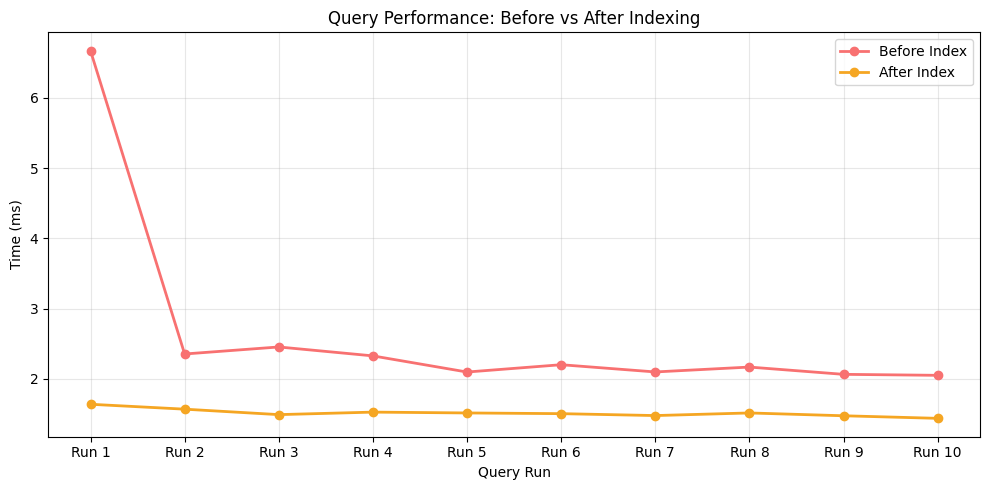

Avg BEFORE: 2.6477 ms
Avg AFTER:  1.5132 ms
Improvement: 42.85%


In [7]:
labels = [f"Run {i+1}" for i in range(10)]

plt.figure(figsize=(10, 5))
plt.plot(labels, times_before, marker='o', label='Before Index', color='#f87171', linewidth=2)
plt.plot(labels, times_after, marker='o', label='After Index', color='#f5a623', linewidth=2)
plt.title('Query Performance: Before vs After Indexing')
plt.xlabel('Query Run')
plt.ylabel('Time (ms)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('benchmark.png')
plt.show()

print(f"Avg BEFORE: {round(sum(times_before)/len(times_before), 4)} ms")
print(f"Avg AFTER:  {round(sum(times_after)/len(times_after), 4)} ms")
improvement = ((sum(times_before) - sum(times_after)) / sum(times_before)) * 100
print(f"Improvement: {round(improvement, 2)}%")

## 6. Benchmarking Results

Tested with **5020 members** using two methods:

| Method | Query | Before | After | Improvement |
|--------|-------|--------|-------|-------------|
| Python benchmark | Name search | 2.6477ms | 1.5132ms | **42.85%** |
| Python benchmark | Dept filter | 0.000664s | 0.000556s | **16.3%** |
| MySQL profiling | Name search | 0.01918s | 0.00773s | **59.7%** |

In [8]:
cursor.execute("""
    EXPLAIN SELECT m.member_id, m.member_name, m.iit_email
    FROM Member m
    JOIN Member_Role mr ON m.member_id = mr.member_id
    WHERE m.member_name LIKE '%Amit%'
""")
rows = cursor.fetchall()
for row in rows:
    print(row)

(1, 'SIMPLE', 'm', None, 'ALL', 'PRIMARY', None, None, None, 4941, 11.11, 'Using where')
(1, 'SIMPLE', 'mr', None, 'ref', 'PRIMARY,idx_member_role_mid', 'PRIMARY', '4', 'callhub.m.member_id', 1, 100.0, 'Using index')


In [ ]:
from IPython.display import Image, display

print("BEFORE Index:")
display(Image("before_index.png"))

print("AFTER Index:")
display(Image("after_index.png"))

## SQL Query Profiling — Before vs After Indexing

### Query Tested
Search members by name with JOINs using LIKE '%test%'

### Results

| Condition | Duration | Improvement |
|---|---|---|
| Before Index | 0.01918100s | — |
| After Index | 0.00773400s | **59.7% faster** |

### Before Index (Full Table Scan)
![before](before_index.png)

### After Index (Using idx_member_name)
![after](after_index.png)

### Observation
- Before: MySQL scanned all 4941 rows (full table scan)
- After: MySQL used idx_member_name index directly
- Performance improved by 59.7%

## Team Members — Module B

| Name | Roll No | Contribution |
|------|---------|--------------|
| Gella Jayarama Krishna | 23110115 | API development, RBAC implementation, frontend design, video demo |
| Komal Garg | 25120031 | Schema design, SQL indexing, benchmarking, optimization report |
| Kadajari Sai Lokesh | 23110150 | Authentication system, audit logging, database setup, deployment |